# Mobile Product Segmentation & Recommendation System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.metrics.pairwise import cosine_similarity


## Data Loading

In [2]:
df = pd.read_csv("Mobile Reviews Sentiment null.csv")

df.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy


## Data Cleaning

In [3]:
df.drop_duplicates(inplace=True)

for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())

review_id               0
customer_name           0
age                     0
brand                   0
model                   0
price_usd               0
price_local             0
currency                0
exchange_rate_to_usd    0
rating                  0
sentiment               0
country                 0
language                0
review_date             0
verified_purchase       0
battery_life_rating     0
camera_rating           0
performance_rating      0
design_rating           0
display_rating          0
helpful_votes           0
source                  0
dtype: int64


## Feature Engineering

In [4]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:

    df[col] = label_encoder.fit_transform(
        df[col].astype(str)
    )

df.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,3762,45,4,15,337.31,41669,6,83.00,2.0,...,2,265,True,1,1,3,2,1,1,1
1,2,9834,18,4,15,307.78,17987,2,5.70,4.0,...,3,523,True,3,2,4,3,2,5,3
2,3,34216,27,1,10,864.53,45011,6,83.00,4.0,...,2,360,True,3,5,3,2,4,8,0
3,4,9946,19,6,17,660.94,31678,0,3.67,3.0,...,0,462,False,1,3,2,1,2,3,1
4,5,45298,38,2,0,792.13,21293,2,5.70,3.0,...,3,1069,True,3,3,2,2,1,0,2


## Feature Scaling

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

X_scaled

array([[-1.73201617, -1.45221569,  1.67108016, ..., -1.27303471,
        -1.08692277, -0.75939537],
       [-1.73194688, -0.99227129, -1.35202399, ..., -0.53344864,
         0.55732652,  0.62263012],
       [-1.7318776 ,  0.85462668, -0.34432261, ...,  0.9457235 ,
         1.79051348, -1.45040811],
       ...,
       [ 1.7318776 , -1.66082684, -1.01612353, ...,  1.68530957,
         0.1462642 , -0.75939537],
       [ 1.73194688,  1.07134291,  0.10354468, ...,  0.20613743,
         0.96838884,  1.31364287],
       [ 1.73201617,  1.01650106,  1.55911334, ...,  0.20613743,
         1.37945116, -0.06838262]], shape=(50000, 22))

## Elbow Method

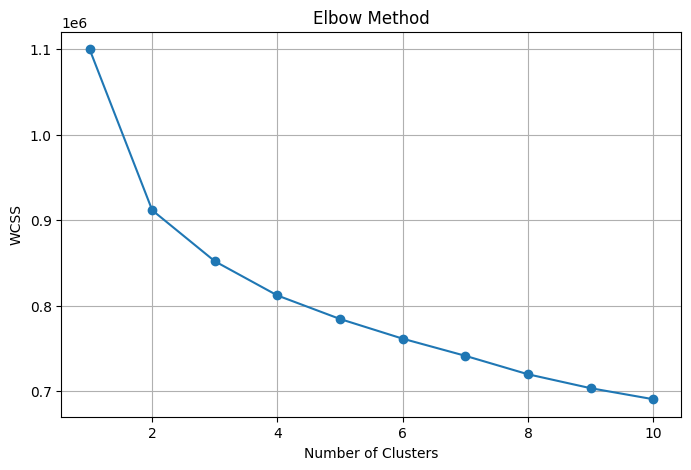

In [6]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid()

plt.show()

## KMeans Clustering (3 Clusters)

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,Cluster
0,1,3762,45,4,15,337.31,41669,6,83.00,2.0,...,265,True,1,1,3,2,1,1,1,1
1,2,9834,18,4,15,307.78,17987,2,5.70,4.0,...,523,True,3,2,4,3,2,5,3,0
2,3,34216,27,1,10,864.53,45011,6,83.00,4.0,...,360,True,3,5,3,2,4,8,0,1
3,4,9946,19,6,17,660.94,31678,0,3.67,3.0,...,462,False,1,3,2,1,2,3,1,2
4,5,45298,38,2,0,792.13,21293,2,5.70,3.0,...,1069,True,3,3,2,2,1,0,2,2


## Cluster Naming

In [8]:
cluster_names = {

    0: "Budget Phones",

    1: "Mid-Range Phones",

    2: "Premium Phones"
}

df["Cluster_Name"] = df[
    "Cluster"
].map(cluster_names)

df.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,Cluster,Cluster_Name
0,1,3762,45,4,15,337.31,41669,6,83.00,2.0,...,True,1,1,3,2,1,1,1,1,Mid-Range Phones
1,2,9834,18,4,15,307.78,17987,2,5.70,4.0,...,True,3,2,4,3,2,5,3,0,Budget Phones
2,3,34216,27,1,10,864.53,45011,6,83.00,4.0,...,True,3,5,3,2,4,8,0,1,Mid-Range Phones
3,4,9946,19,6,17,660.94,31678,0,3.67,3.0,...,False,1,3,2,1,2,3,1,2,Premium Phones
4,5,45298,38,2,0,792.13,21293,2,5.70,3.0,...,True,3,3,2,2,1,0,2,2,Premium Phones


## Recommendation System

In [9]:
similarity_matrix = cosine_similarity(
    X_scaled
)

def recommend_mobile(index,
                      top_n=5):

    similarity_scores = list(
        enumerate(
            similarity_matrix[index]
        )
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x:x[1],
        reverse=True
    )

    recommendations = similarity_scores[
        1:top_n+1
    ]

    return recommendations

recommend_mobile(0)

[(20706, np.float64(0.9417765738090434)),
 (1205, np.float64(0.92140806788071)),
 (9984, np.float64(0.9212267976494535)),
 (6583, np.float64(0.9078685914281834)),
 (3768, np.float64(0.9015316220965007))]